# 🎓 **Homework #3** 🎓

---

### 👤 **Assigner**:  
**Malkova Ksenia**

### ✍️ **Contacts**:  
- [kemalkova@edu.hse.ru](mailto:kemalkova@edu.hse.ru)

- [@ksu_marshmallow](https://t.me/ksu_marshmallow)

### 🔥 **Deadline** 🔥:  
- **11.03.2025**
---

## 📝 Requirements & Tips

- Значения всех параметров (матрицы вероятностей, размерности и т.п.) должны определяться один раз, после чего для вычислений уже используются переменные
- "Хардкодить"числа внутри кода не допускается
- Начальное распределение - **стационарное** (знать, что это)
- Протестировать алгоритмы для $L = 100, 500, 1000$. Добавить защиту от потери точности через `logsumexp` и/или нормализацию (см. учебник Durbin et al)

## 📦 Libraries and Settings

In [ ]:
import warnings
from pathlib import Path
from tqdm import tqdm

import numpy as np
from scipy.special import logsumexp
from sklearn.preprocessing import LabelEncoder

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

sns.set(style="whitegrid", context="notebook", palette="pastel")
warnings.simplefilter('ignore')

In [ ]:
DATA_FOLDER = Path.home() / 'PopGen_Models/data/HW3'
SEED = 42

## 📊  Data

In [3]:
symbols = np.arange(1, 7)
states = ['F', 'L']

symbols_encoder = LabelEncoder().fit(symbols)
states_encoder = LabelEncoder().fit(states)

symbols_coded = symbols_encoder.transform(symbols)
states_coded = states_encoder.transform(states)

print(f"Symbols: {symbols_coded} \nStates: {states_coded}")

Symbols: [0 1 2 3 4 5] 
States: [0 1]


# **Main HW Part**

## 🧬 Task 1. Generator

>Для заданных матриц переходных вероятностей $M$ и эмиссионных вероятностей $E$ сгенерировать последовательность σ скрытых состояний и последовательность $\varepsilon$ наблюдений длины $L$. В качестве начального распределения использовать стационарное распределение матрицы $M$ (собственный вектор, соответсвтующий единичному собственному значению).

In [4]:
M = np.array([
    # F, L
    [0.95, 0.05],   # F
    [0.1, 0.9]      # L
])

E = np.array([
    [1/6, 1/6, 1/6, 1/6, 1/6, 1/6],         # F
    [1/10, 1/10, 1/10, 1/10, 1/10, 1/2]     # L
])

### 💡**2.1 Concept**

**Стационарное распределение** - это вектор вероятностей, который остается неизменным после применения матрицы переходных вероятностей. Формально, для матрицы переходных вероятностей 
$M$ стационарное распределение $\pi$ удовлетворяет условию $$\pi = \pi \cdot M$$

Стационарное распределение является *собственным вектором* матрицы $M$, соответствующим собственному значению 1. Оно описывает долгосрочное поведение системы, то есть вероятности нахождения в каждом состоянии после большого числа шагов.

Для нахождения стационарного распределения $\pi$:
1. $\pi = \pi \cdot M$
2. $\sum_i \pi_i = 1$

Наша матрица $M$:
$$M = \begin{pmatrix} 0.95 && 0.05 \\ 0.1 && 0.9 \end{pmatrix}$$

Распишем и решим СЛУ (ищем левый собственный вектор, поэтому транспонировали $M$):
$$
\begin{cases}
    \pi_1 = 0.95 \cdot \pi_1 + 0.1 \cdot \pi_2, && (1) \\
    \pi_2 = 0.05 \cdot \pi_1 + 0.9 \cdot \pi_2, && (2) \\
    \pi_1 + \pi_2 = 1 && (3)
\end{cases}
$$

В $(1)$ подставим $\pi_1$ из $(3)$:
$$
\begin{gather}
    0.05 \cdot \pi_1 - 0.1 \cdot (1 - \pi_1) = 0 \\
    0.15 \cdot \pi_1 = 0.1
\end{gather}
$$

$$
\begin{gather}
    \pi_1 = \frac{2}{3} && \text{ и } && \pi_2 = \frac{1}{3}
\end{gather}
$$

Тогда стационарное распределение $\pi$: $$\pi = [\frac{2}{3} \space \space \space \frac{1}{3}]$$

На основе найденного стационарного распределения $\pi$ генерируем скрытые состояния $\sigma$:
1. Начальное состояние $\sigma_0$ - в соответствие с $\pi$. 
2. Исходя из $E$ и $\sigma_0$ генерируем первое наблюдение $\varepsilon_0$
3. Для каждого шага от $t$ до $L-1$:
    - Переходим из $t$ в $t+1$, исходя из transition matrix $M$
    - Генерируем наблюдение $\varepsilon_t$, исходя из emmission matrix $E$

### 🔧 **2.2 Implementation**

Ищем стационарное распределение:

In [54]:
eig_values, eig_vectors = np.linalg.eig(M.T)

pi = eig_vectors[:, np.argmax(np.isclose(eig_values, 1))]
pi /= pi.sum()

pi

array([0.66666667, 0.33333333])

Генерируем скрытые состояния, исходя из стационарного распределения:

In [ ]:
def generate_hidden(states_set: np.ndarray,
                    symbols_set: np.ndarray,
                    transition_matrix: np.ndarray,
                    emission_matrix: np.ndarray,
                    pi: np.ndarray,
                    L: int = 100,
                    seed: int = None):
    """
    Generates a sequence of hidden states and observations from a Hidden Markov Model (HMM)

    Parameters:
        states_set:         Array of state indices (0, 1, ..., num_states-1)
        symbols_set:        Array of observation indices (0, 1, ..., num_symbols-1)
        transition_matrix:  [num_states x num_states] matrix, where entry (i, j) is the probability
                            of transitioning from state i to state j
        emission_matrix:    [num_states x num_symbols] matrix, where entry (i, k) is the probability
                            of emitting observation k from state i
        pi:                 Initial state distribution summing to 1, [num_states, ]
        L:                  Length of the generated sequence (defaults to 100)

    Returns:
        Tuple[np.ndarray, np.ndarray]: 
            - Hidden states sequence of length L (indices from `states_set`)
            - Observed symbols sequence of length L (indices from `symbols_set`)

    UPD: all docstrings are generated with chatgpt because я очень ленивая
    """

    if seed is not None:
        np.random.seed(seed)

    num_states, num_symbols = len(states_set), len(symbols_set)

    # Validations
    assert transition_matrix.shape == (num_states, num_states), "Transition matrix shape mismatch"
    assert emission_matrix.shape == (num_states, num_symbols), "Emission matrix shape mismatch"
    assert pi.shape == (num_states, ), "Initial distribution shape mismatch"

    assert np.allclose(np.sum(transition_matrix, axis=1), 1), "Transition matrix rows must sum to 1"
    assert np.allclose(np.sum(emission_matrix, axis=1), 1), "Emission matrix rows must sum to 1"
    assert np.allclose(np.sum(pi), 1), "Initial distribution must sum to 1"

    # Initialize first hidden state
    initial_state = np.random.choice(states_set, p=pi)
    initial_observation = np.random.choice(symbols_set, p=emission_matrix[initial_state])
    
    hidden_states = [initial_state]
    observations = [initial_observation]
    
    # Generate hidden states and observations according to transition and emission probabilities
    for t in tqdm(range(1, L), colour='GREEN', desc='Generating hidden states and observations...'):
        state_prev = hidden_states[t-1]
        
        state_current = np.random.choice(states_set, p=transition_matrix[state_prev])
        observation_current = np.random.choice(symbols_set, p=emission_matrix[state_current])

        hidden_states.append(state_current)
        observations.append(observation_current)
    
    return np.array(hidden_states), np.array(observations)

In [7]:
all_hidden_states, all_observations = [], []
length_seq = [100, 500, 1000]

for l in length_seq:

    print(f"L = {l}")

    hidden_states, observations = generate_hidden(
        states_set=states_coded,
        symbols_set=symbols_coded,
        transition_matrix=M,
        emission_matrix=E,
        pi=pi,
        L=l,
        seed=SEED
    )

    all_hidden_states.append(hidden_states)
    all_observations.append(observations)

L = 100


Generating hidden states and observations...: 100%|██████████| 99/99 [00:00<00:00, 21401.72it/s]


L = 500


Generating hidden states and observations...: 100%|██████████| 499/499 [00:00<00:00, 22746.33it/s]


L = 1000


Generating hidden states and observations...: 100%|██████████| 999/999 [00:00<00:00, 26394.56it/s]


Не знаю, как их нормально изобразить, будет так..

In [48]:
def plot_observations(obs: np.ndarray, title: str=None):    
    matrix = np.zeros((6, len(obs)))    
    for i, sym in enumerate(obs):
        matrix[sym, i] = 1
    
    plt.figure(figsize=(12, 4))
    sns.heatmap(matrix, cmap="Blues", cbar=False, xticklabels=50, yticklabels=range(6))

    if title is not None:
        plt.title(title)
    
    plt.xlabel("Timestep")
    plt.ylabel("Observed Symbol")
    plt.show()

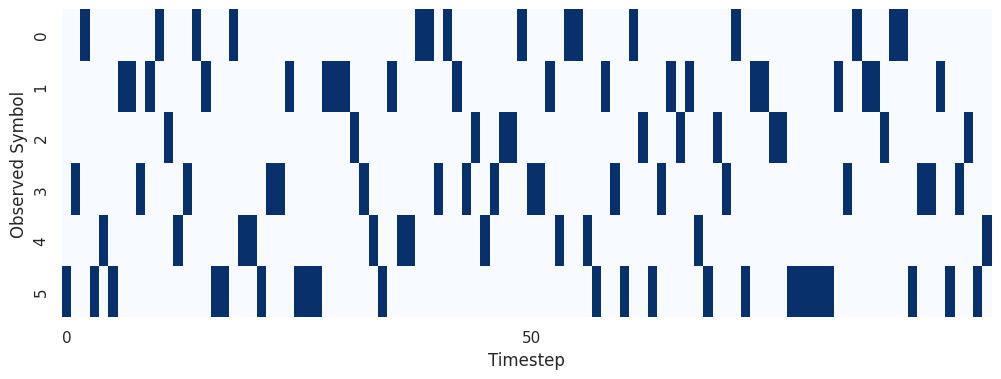

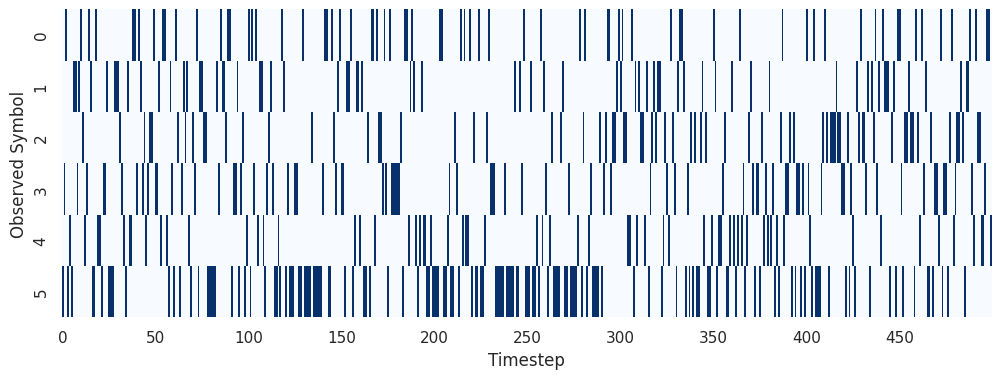

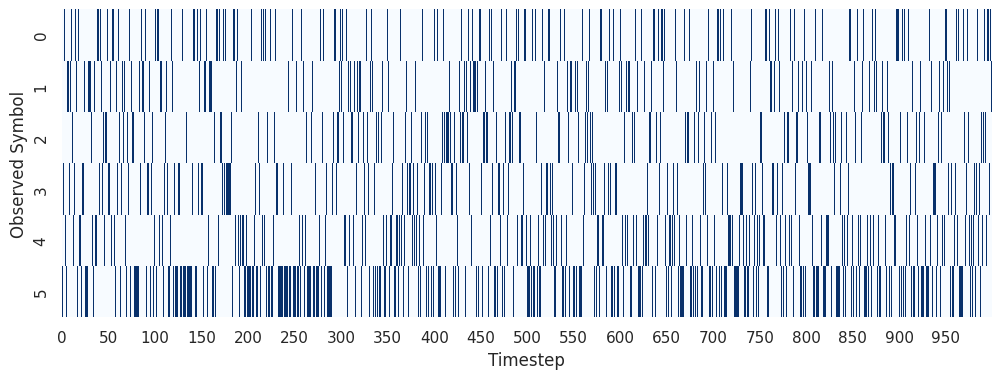

In [49]:
for obs in all_observations:
    plot_observations(obs)

---

## 🧬 Task 2. Viterbi algorithm

> Реализовать алгоритм Витерби: для данных $M$, $E$ и $\varepsilon$ найти $$\sigma_v = \argmax_{\sigma'} P(\sigma', \varepsilon | M, E)$$ Визуализировать результат: построить на графике $\sigma$ и $\sigma_v$ (на оси $x$ позиция, на оси $y$ - номер состояния).

### 💡**2.1 Concept**

Алгоритм Витерби позволяет найти **наиболее вероятный путь**, по которому была сгенерирована наблюдаемая последовательность.

Пусть $v_k(i)$ — наибольшая вероятность пути длиной $i$, заканчивающегося в состоянии $\sigma_k$, при известных наблюдениях $\varepsilon_1, \dotsc, \varepsilon_i$. Тогда для следующего наблюдения $\varepsilon_{i+1}$ вероятность обновляется по формуле:

$$
v_l(i+1) = e_l (\varepsilon_{i+1}) \max_k (v_k(i) \cdot m_{kl}),
$$

где:
- $e_l (\varepsilon_{i+1})$ - вероятность эмиссии наблюдения $\varepsilon_{i+1}$ в состоянии $\sigma_l$,
- $m_{kl}$ - вероятность перехода из состояния $\sigma_k$ в состояние $\sigma_l$.

#### 1. Инициализация $(i=1)$

Для первого наблюдения: 

$$v_k(1) = \pi_k e_k(\varepsilon_1), \quad \forall k$$

где $\pi_k$ - начальное распределение состояний (в нашем случае - стационарное распределение матрицы переходов $M$).  

#### 2. Рекурсия $(i = 2, \dotsc, L)$

На каждом шаге $i$ вычисляем:

$$
\begin{gather}
    v_l(i) = e_l(\varepsilon_i) \max_k (v_k (i-1) \cdot m_{kl}) \\
    \text{ptr}_i(l) = \argmax_k (v_k (i-1) \cdot m_{kl})
\end{gather}
$$

где:
- $m_{kl}$ - вероятность перехода из состояния $\sigma_k$ в $\sigma_l$,
- $e_l (\varepsilon_i)$ - вероятность эмиссии наблюдения $\varepsilon_i$ в состоянии $\sigma_l$,
- $\text{ptr}_i(l)$ - **оптимальное предыдущее состояние**, из которого пришли в $l$ на шаге $i$.

#### 3. Обратный проход $(i = L, \dotsc, 1)$

1. Находим наиболее вероятное конечное состояние:

$$\sigma_{v, L} = \argmax_k v_k (L)$$

2. Восстанавливаем наиболее **оптимальный** путь, двигаясь назад по $\text{ptr}$:
$$\sigma_{v, i-1} = \text{ptr}_i (\sigma_{v, i})$$

### 🔧 **2.2 Implementation**

In [86]:
def viterbi(states_set: np.ndarray,
            transition_matrix: np.ndarray,
            emission_matrix: np.ndarray,
            pi: np.ndarray,
            observations: np.ndarray):
    """
    Implements the Viterbi algorithm to find the most probable hidden state sequence 
    given a sequence of observations.

    Parameters:
        states_set:         Array of state indices (0, 1, ..., num_states-1)
        transition_matrix:  [num_states x num_states] matrix, where entry (i, j) is the probability
                            of transitioning from state i to state j
        emission_matrix:    [num_states x num_symbols] matrix, where entry (i, k) is the probability
                            of emitting observation k from state i
        pi:                 Initial state distribution summing to 1, [num_states, ]
        observations:       Sequence of observed symbols (indices from `symbols_set`)

    Returns:
        np.ndarray: Most probable sequence of hidden states
    """

    L = len(observations)
    num_states = len(states_set)

    # Viterbi table (log probabilities to avoid underflow)
    viterbi_log = np.full((L, num_states), -np.inf)      # Stores log probas of being in state s at time t
    backpointer = np.zeros((L, num_states), dtype=int)   # Stores state k from which we arrived to s

    # 1. Initialization: v_k(0) = π_k * e_k(ε_0)
    viterbi_log[0] = np.log(pi) + np.log(emission_matrix[:, observations[0]])

    # 2. Recursion step:  v_k(t) = e_k(ε_{t}) * max_l [ v_l(t-1) * m_{lk} ]
    for t in tqdm(range(1, L), colour='GREEN', desc='Recursion...'):
        log_probs = viterbi_log[t-1] + np.log(transition_matrix) + np.log(emission_matrix[:, observations[t]])

        # Store the most probable previous state
        backpointer[t] = np.argmax(log_probs, axis=1)

        # Store the best log-probability of this prev state
        viterbi_log[t] = np.max(log_probs, axis=1)

    # 3. Backtracking
    best_path = np.zeros(L, dtype=int)

    # Most probable last state
    best_path[-1] = np.argmax(viterbi_log[-1])

    # For each step we know, from which state we arrived here (most probable)
    for t in range(L-2, -1, -1):
        best_path[t] = backpointer[t+1, best_path[t+1]]

    return best_path

In [87]:
all_best_hidden_path = []

for observations in all_observations:
    print(f"L = {observations.shape[0]}")

    best_hidden_path = viterbi(
        observations=observations,
        pi=pi,
        states_set=states_coded,
        transition_matrix=M,
        emission_matrix=E,
    )

    all_best_hidden_path.append(best_hidden_path)

L = 100


Recursion...: 100%|██████████| 99/99 [00:00<00:00, 54392.99it/s]


L = 500


Recursion...: 100%|██████████| 499/499 [00:00<00:00, 46959.94it/s]


L = 1000


Recursion...: 100%|██████████| 999/999 [00:00<00:00, 98028.02it/s]


In [88]:
image = plt.imread('cat.webp')

def plot_viterbi(predicted_states, title: str=None):
    L = len(predicted_states)
    x = np.arange(L)

    _, ax = plt.subplots(figsize=(12, 6))

    x, predicted_states = np.atleast_1d(x, predicted_states)
    for x0, y0 in zip(x, predicted_states):
        image_box = OffsetImage(image, zoom=0.1)
        ab = AnnotationBbox(image_box, (x0, y0), frameon=False)
        ax.add_artist(ab)
 
    ax.plot(x, predicted_states, alpha=0.3, color='blue')

    ax.set_xlabel("Time Step")
    ax.set_ylabel("State")
    ax.set_yticks([0, 1])
    ax.set_ylim(-0.5, 1.5)

    if title:
        ax.set_title(title)

    ax.grid(False)

    plt.show()

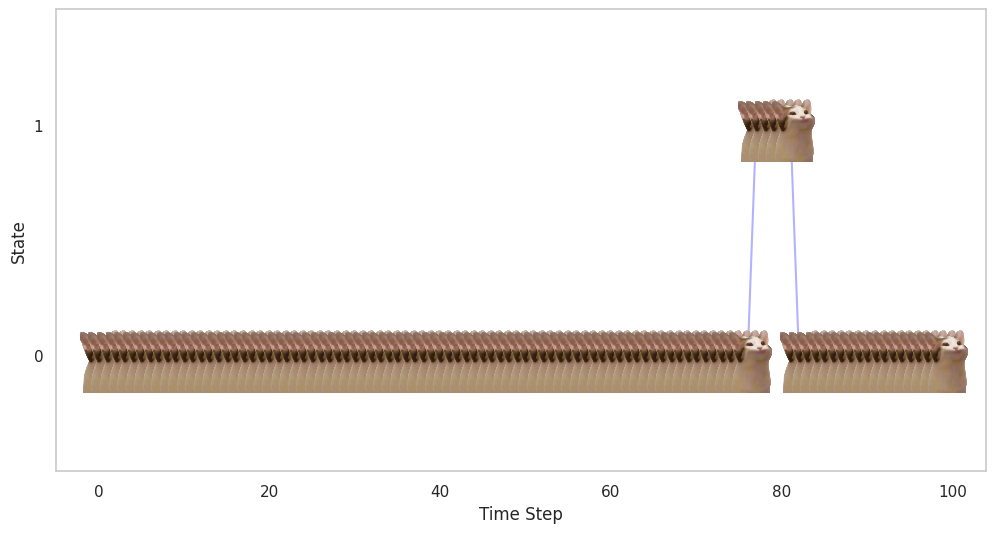

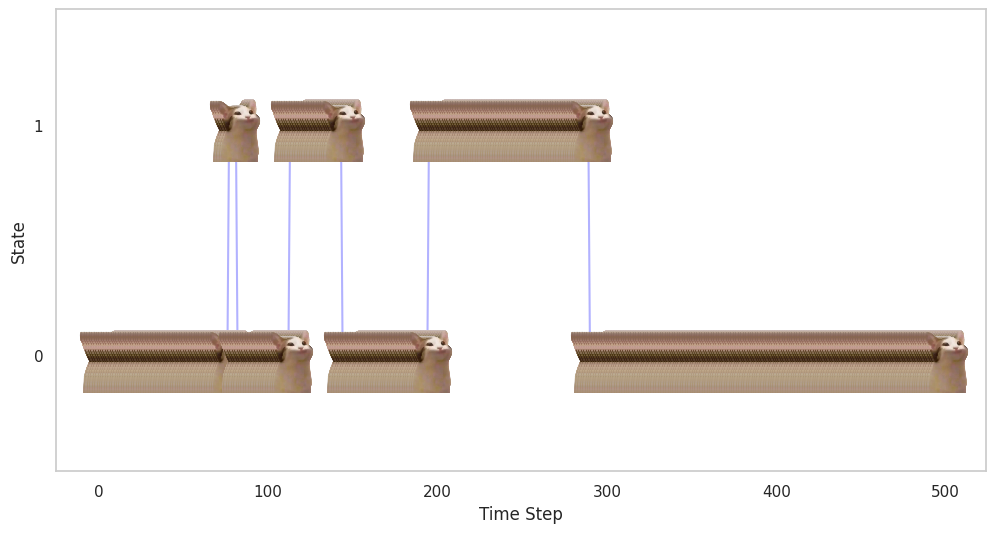

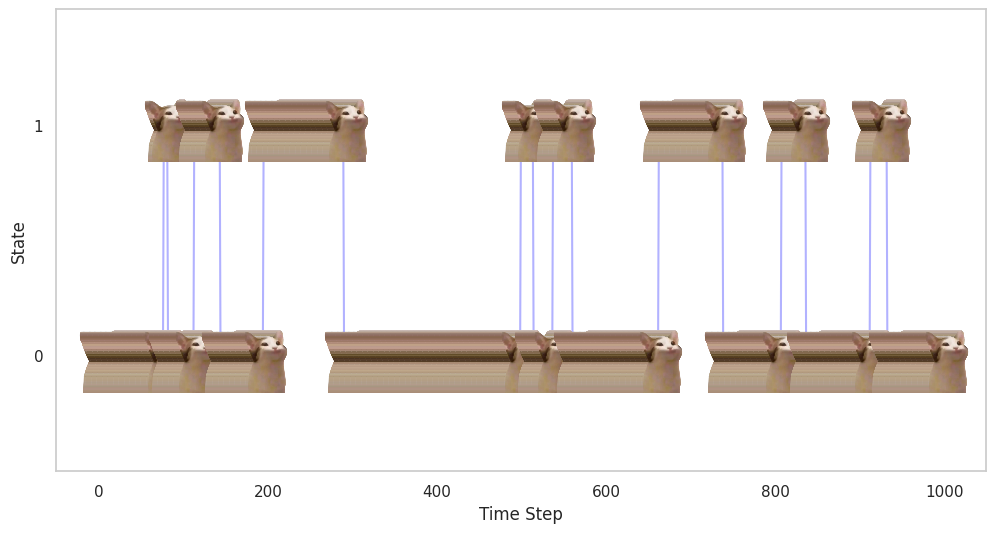

In [89]:
for predicted_states in all_best_hidden_path:
    plot_viterbi(predicted_states)

огонь да

## 🧬 Task 3. Forward-backward pass

>Реализовать алгоритмы прямого и обратного хода (особое внимание уделите инициализации алгоритмов!). Вычислить $P(\varepsilon)$ с помощью обоих алгоритмов.

Полная вероятность "получить" последовательность наблюдений $\varepsilon$ - сумма вероятностей по всем возможным путям $\sigma'$ сгенерировать эту последовательность:
$$
P(\varepsilon) = \sum_{\sigma'} P(\varepsilon, \sigma')
$$


### **I. Forward-алгоритм**
Определим forward-term $f_k(i)$ как вероятность наблюдать первые $i$ символов последовательности, если $i$-е скрытое состояние равно $k$ (соответствует $v_k(i)$ из Витерби алгоритма):

$$f_k(i) = (\varepsilon_1, \dotsc, \varepsilon_i, \sigma_i = k)$$

*вообще все, чем отличается forward-алгоритм от Витерби - замена максимума на сумму в рекурсии

**1. Инициализация** $(i=1)$:  
$$
f_k(1) = \pi_k e_k(\varepsilon_1), \quad \forall k
$$

где $\pi_k$ - стационарное распределение (начальная вероятность быть в состоянии $k$).

**2. Рекурсия** $(i = 2, \dotsc, L)$:
$$
\begin{gather}
    f_l(i) = e_l (\varepsilon_i) \sum_k f_k (i-1) m_{kl},
\end{gather}
$$

где:
- $m_{kl}$ — вероятность перехода из состояния $\sigma_k$ в $\sigma_l$,
- $e_l (\varepsilon_i)$ — вероятность эмиссии наблюдения $\varepsilon_i$ в состоянии $\sigma_l$.

**3. Остановка**  
$$
\begin{gather}
    P(x) = \sum_k f_k(L)
\end{gather}
$$

In [13]:
def forward_algorithm(states_set: np.ndarray,
                      transition_matrix: np.ndarray,
                      emission_matrix: np.ndarray,
                      pi: np.ndarray,
                      observations: np.ndarray,
                      disable: bool=False):
    """
    Computes the forward probabilities f_t(s) using the Forward algorithm.

    Parameters:
        states_set (np.ndarray): Array of state indices (0, 1, ..., N-1).
        transition_matrix (np.ndarray): N x N matrix of transition probabilities.
        emission_matrix (np.ndarray): N x M matrix of emission probabilities.
        pi (np.ndarray): Initial state distribution (length N).
        observations (np.ndarray): Sequence of observed symbols (indices from symbols_set).

    Returns:
        np.ndarray: Forward probability matrix (log scale) of shape (L, N).
        float: Log-probability P(ε) computed using the forward algorithm.
    """

    L = len(observations)
    N = len(states_set)

    # Forward matrix in log-space
    # Хранит вероятности (log) на кжадом шаге для каждого состояния
    forward_log = np.full((L, N), -np.inf)

    # 1. Initialization: f_k(1) = log(π_k) + log(e_k(ε_1))
    # Вероятность наблюдать первое наблюдение в каждом состояние (сори за тавтологию)
    #   - π_k - начальная вероятность быть в состоянии k
    #   - e_k(ε_1) - вероятность эмиссии первого наблюдения ε_1 в k-м состоянии
    forward_log[0] = np.log(pi) + np.log(emission_matrix[:, observations[0]])

    # 2. Recursion step:
    # Для каждого шага t вычисляем вероятность быть в состоянии k на шаге t
    for t in tqdm(range(1, L), colour='YELLOW', desc='Forward pass...', disable=disable):
        for s in states_set:
            # f_s(t) = e_s(ε_t) * sum_s' {f_s'(t-1) * m_s's}
            # - e_s(ε_t) - вероятность состоянию s (текущему) сгенерировать ε_t
            # - sum_s' - сумма вероятностей всех путей, ведущих в s
            forward_log[t, s] = np.log(emission_matrix[s, observations[t]]) + logsumexp(forward_log[t - 1] + np.log(transition_matrix[:, s]))

    # 3. Stop: P(ε) = logsumexp(f_k(L))
    # Общая вероятность наблюдаемой последовательности длины L = сумма по всем состояниям в L-1
    log_P_obs = logsumexp(forward_log[-1])

    return forward_log, log_P_obs

### **II. Backward-алгоритм**

Определим backward-term $b_k(i)$ как вероятность увидеть оставшуюся часть последовательности $\varepsilon_{i+1}, \dotsc, \varepsilon_L$, если в момент $i$ мы в состоянии $\sigma_i = k$:

$$
    b_k(i) = P(\varepsilon_{i+1}, \dotsc, \varepsilon_L | \sigma_i = k)
$$

**1. Инициализация** $(i=L)$:  
$$
b_L(0) = 1, \quad \forall k
$$

(нет дополнительных состояний после $L$-го шага, поэтому вероятности равны 1).

**2. Рекурсия** $(i=L-1, \dotsc, 1)$:
$$
\begin{gather}
    b_k(i) = \sum_l m_{kl} e_l (\varepsilon_{i+1}) b_l (i+1)
\end{gather}
$$

**3. Остановка**  
$$
\begin{gather}
    P(\varepsilon) = \sum_k \pi_k e_k(\varepsilon_1) b_k (1)
\end{gather}
$$

In [14]:
def backward_algorithm(states_set: np.ndarray,
                       transition_matrix: np.ndarray,
                       emission_matrix: np.ndarray,
                       observations: np.ndarray,
                       disable: bool=False):
    """
    Computes the backward probabilities β_t(s) using the Backward algorithm.

    Parameters:
        states_set (np.ndarray): Array of state indices (0, 1, ..., N-1).
        transition_matrix (np.ndarray): N x N matrix of transition probabilities.
        emission_matrix (np.ndarray): N x M matrix of emission probabilities.
        observations (np.ndarray): Sequence of observed symbols (indices from symbols_set).

    Returns:
        np.ndarray: Backward probability matrix (log scale) of shape (L, N).
        float: Log-probability P(ε) computed using the backward algorithm.
    """

    L = len(observations)
    N = len(states_set)

    # Backward matrix in log-space
    # Хранит вероятности (log) на кжадом шаге для каждого состояния
    backward_log = np.full((L, N), -np.inf)

    # 1. Initialization: b_L(0) = 1, т.е. log(1) = 0
    # В последний момент времени мы знаем, что нет дальнейших наблюдений, поэтому вероятность равна 1
    backward_log[-1] = 0

    # 2. Recursion step:
    # Для каждого шага t - считаем вероятность увидеть оставшуюся часть последовательности
    for t in tqdm(range(L-2, -1, -1), colour='CYAN', desc='Backward pass...', disable=disable):
        for s in states_set:
            # b_s(t) = sum_s' {m_ss' * e_s'(ε_{t+1}) * b_s'(t+1)}
            # Суммируем по всем состояниям s', в которые можно перейти 
            # m_ss' - переходная вероятность из текущего s в следующее s'
            # e_s' - вероятность эмиссии наблюдаемого символа на следующем состоянии в s' 
            # b_s' (t+1) - уже посчитанные такие же backward вероятности (для оставшейся после t+1 части)
            backward_log[t, s] = logsumexp(np.log(transition_matrix[s]) \
                                           + np.log(emission_matrix[:, observations[t+1]]) \
                                           + backward_log[t+1]
                                           )

    # 3. Stop: P(ε) = logsumexp(log(π_s) + log(e_s(ε_1)) + b_s(1))
    # Полная вероятность наблюдаемой последовательности длины L 
    # = начальное распределение состояний * вероятность эмиссии первого наблюдения в этих состояниях
    log_P_obs = logsumexp(np.log(pi) + np.log(emission_matrix[:, observations[0]]) + backward_log[0])

    return backward_log, log_P_obs

### Testing

$P(x)$, полученные forward- и backward-алгоритмами, должны сходится

In [15]:
for observations in all_observations:
    print(f"L = {len(observations)}")

    forward_log, log_P_forward = forward_algorithm(states_set=states_coded, 
                                                 transition_matrix=M, 
                                                 emission_matrix=E, 
                                                 pi=pi, 
                                                 observations=observations)
    
    backward_log, log_P_backward = backward_algorithm(states_set=states_coded, 
                                                  transition_matrix=M, 
                                                  emission_matrix=E, 
                                                  observations=observations)

    print(f"Log P(ε) from Forward: {log_P_forward:.4f}")
    print(f"Log P(ε) from Backward: {log_P_backward:.4f}")
    print('-'*100)

L = 100


Backward pass...: 100%|██████████| 99/99 [00:00<00:00, 10341.35it/s]


Log P(ε) from Forward: -178.2200
Log P(ε) from Backward: -178.2200
----------------------------------------------------------------------------------------------------
L = 500


Backward pass...: 100%|██████████| 499/499 [00:00<00:00, 10142.41it/s]


Log P(ε) from Forward: -861.7509
Log P(ε) from Backward: -861.7509
----------------------------------------------------------------------------------------------------
L = 1000


Backward pass...: 100%|██████████| 999/999 [00:00<00:00, 10316.17it/s]

Log P(ε) from Forward: -1730.2016
Log P(ε) from Backward: -1730.2016
----------------------------------------------------------------------------------------------------


all coincidences are random except $P(\varepsilon)$

## 🧬 Task 4. A posteriory decoding 

>Реализовать апостериорное декодирование. Визуализировать результат: построить график $P(\text{state}_0 | \varepsilon) (l)$

Апостериорное декодирование находит наиболее вероятное состояние на каждом шаге $t$, учитывая как предыдущие наблюдения, так и будущие. 

Для каждого шага $t$ апостериорное декодирование позволяет найти **апостериорную вероятность** нахождения в состоянии $\sigma_t = k$, учитывая всю последовательность наблюдений:
$$
    P(\sigma_t = k | \varepsilon) = \frac{P(\varepsilon | \sigma_t = k) \cdot P (\sigma_t = k)}{P(\varepsilon)},
$$
где
- $P(\sigma_t = k | \varepsilon)$ - апостериорная вероятность того, что в момент времени $t$ система находится в состоянии $k$, учитывая всю последовательность наблюдений $\varepsilon$
- $P(\varepsilon | \sigma_t = k)$ - вероятность наблюдать последовательность данных при условии, что в момент времени $t$ состояние равно $k$ (это вычисляется с использованием алгоритма forward- или backward-)
- $P(\sigma_t = k)$ - **априорная** вероятность того, что система находится в состоянии $k$ (начальное распределение $\pi_k$)
- $P(\varepsilon)$ - полная вероятность наблюдат последовательность наблдюений $\varepsilon$ (нормализующая константа - гарантирует, что все вероятности суммируются до 1; можно вычислить через сумму по всем состояниям для всех возможных путей, т.е. через forward- или backward-алгоритм).

**Алгоритм**
1. Для каждого шага $t$ мы вычисляем forward- и backward- вероятности ($f_k(t)$ и $b_k(t)$ соответственно) - насколько вероятно наблюдать всю последовательность, если в момент времени $t$ мы находимся в состоянии $k$?
2. Вычисляем апостериорную вероятность для каждого состояния: $$P(\sigma_t = k | \varepsilon) = \frac{f_k(t) \cdot b_k (t)}{P(\varepsilon)}$$
3. Итоговую нормализующую константу $P(\varepsilon)$ можно вычислить через backward- или forward-алгоритмы:
$$
\begin{gather}
    P(\varepsilon) = \sum_k f_k (L) && \text{(forward-algo)} \\
    \text{ or } && \\
    P(\varepsilon) = \sum_k \pi_k e_k(\varepsilon_1)b_k(1) && \text{(backward-algo)} \\
\end{gather}
$$

In [16]:
def posterior_decoding(states_set: np.ndarray, 
                       transition_matrix: np.ndarray, 
                       emission_matrix: np.ndarray, 
                       pi: np.ndarray, 
                       observations: np.ndarray):
    """
    Computes the posterior probabilities P(σ_i | ε) using the forward and backward probabilities.

    Parameters:
        states_set (np.ndarray): Array of state indices (0, 1, ..., N-1).
        transition_matrix (np.ndarray): N x N matrix of transition probabilities.
        emission_matrix (np.ndarray): N x M matrix of emission probabilities.
        pi (np.ndarray): Initial state distribution (length N).
        observations (np.ndarray): Sequence of observed symbols (indices from symbols_set).

    Returns:
        np.ndarray: Posterior probability matrix (log scale) of shape (L, N).
    """
    # Step 1: Calculate forward and backward probabilities using the existing algorithms
    alpha_log, P_obs = forward_algorithm(states_set=states_set,
                                         transition_matrix=transition_matrix,
                                         emission_matrix=emission_matrix,
                                         pi=pi,
                                         observations=observations)
    
    beta_log, _ = backward_algorithm(states_set=states_set,
                                     transition_matrix=transition_matrix,
                                     emission_matrix=emission_matrix,
                                     observations=observations)

    # Step 2: Calculate posterior probabilities for each state at each time step
    # P(σ_i = k | ε) = f_k(i) * b_k(i) / P(ε), but using log scale:
    posterior_log = alpha_log + beta_log - P_obs  # Log of the posterior probability

    return posterior_log

In [17]:
all_posterior_prob = []

for observations in all_observations:
    print(f"L = {len(observations)}")

    posterior_log = posterior_decoding(
        states_set=states_coded,
        transition_matrix=M,
        emission_matrix=E,
        pi=pi,
        observations=observations
    )

    posterior_prob = np.exp(posterior_log)
    all_posterior_prob.append(posterior_prob)

L = 100


Backward pass...: 100%|██████████| 99/99 [00:00<00:00, 8739.79it/s]


L = 500


Backward pass...: 100%|██████████| 499/499 [00:00<00:00, 10944.83it/s]


L = 1000


Backward pass...: 100%|██████████| 999/999 [00:00<00:00, 10172.96it/s]


In [18]:
def plot_state_proba(posterior_prob, observations, title: str = None):
    num_states = posterior_prob.shape[1]

    plt.figure(figsize=(14, 6))

    for state_idx in range(num_states):
        plt.plot(range(len(observations)), posterior_prob[:, state_idx], label=f"State {state_idx}")
    
    if title:
        plt.title(title)
    plt.xlabel(r"Time Step $t$")
    plt.ylabel(r"$P(\sigma_t | \varepsilon)$")

    plt.grid(False)
    plt.legend(loc='upper right')
    plt.show()

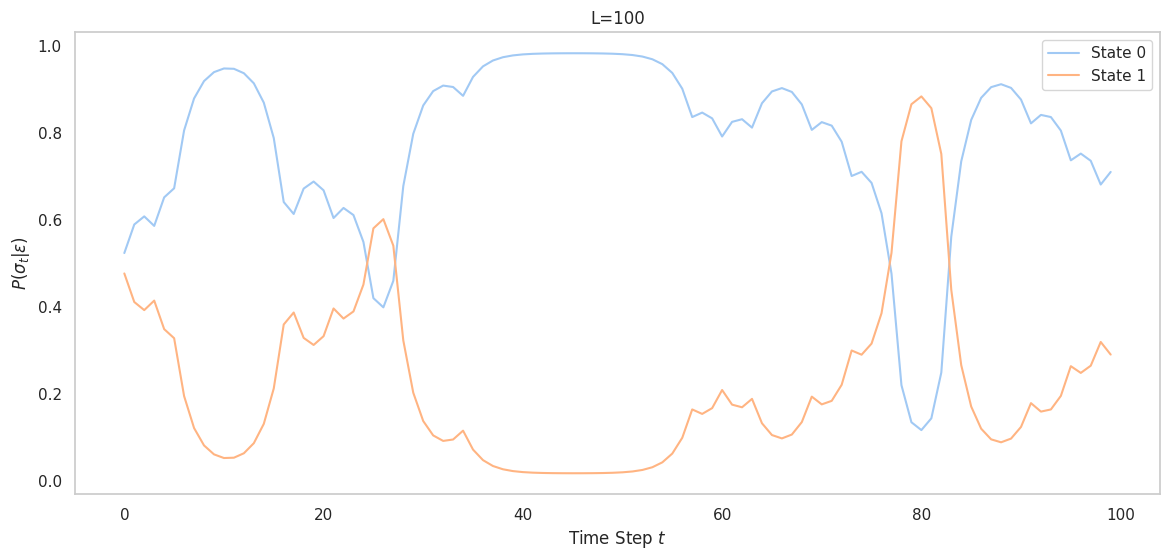

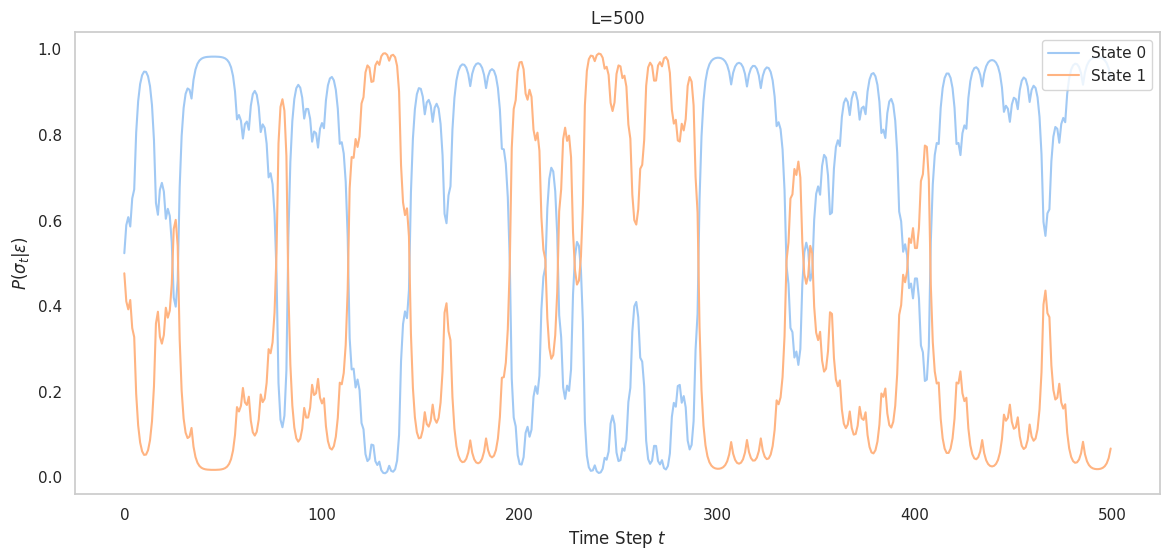

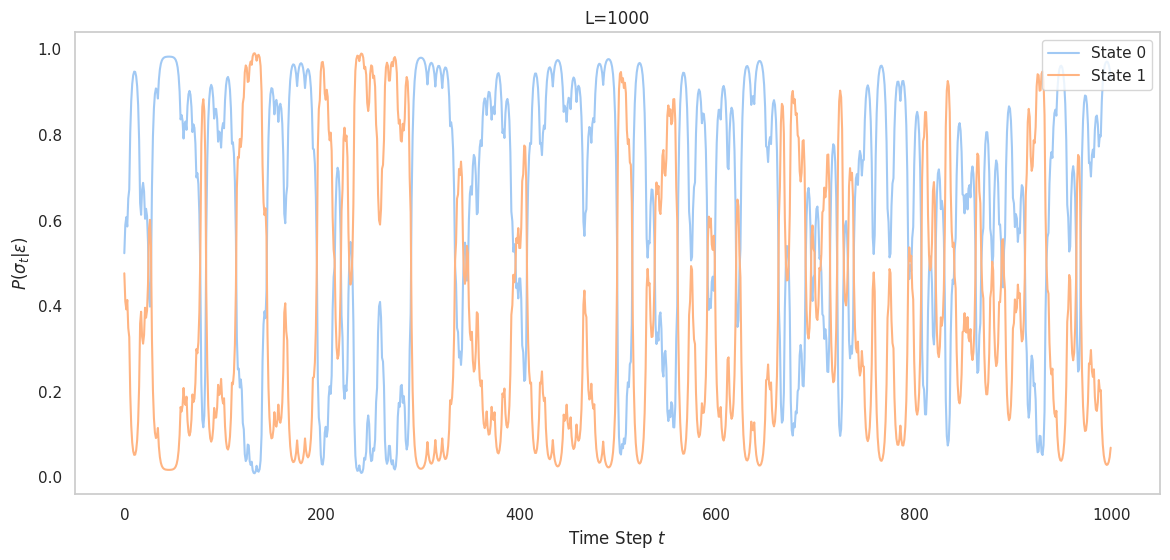

In [19]:
for observations, posterior_prob in zip(all_observations, all_posterior_prob):
    plot_state_proba(posterior_prob, observations, title=f"L={len(observations)}")

## 🧬 Task 5. Baum-Welch algorithm
>Реализовать алгоритм Баума-Велша

Алгоритм **Баума-Велша** - **итеративный метод оценки параметров** HMM, когда у нас есть только наблюдаемые данные $\varepsilon$, но неизвестны параметры:  
- **матрица переходов** $M = \{m_{kl}\} $,
- **матрица эмиссий** $E = \{e_k(\varepsilon)\}$
- **начальное распределение** $\pi$

Этот алгоритм является частным случаем **EM-алгоритма (Expectation-Maximization)**, который чередует два шага:  

### 1. **Expectation (E-шаг)**
Находим *апостериорные* вероятности нахождения в состояниях на основе текущих параметров

Используем **forward-backward алгоритм**, чтобы вычислить:
- $\gamma_k(t)$- вероятность нахождения в $k$-м состоянии на шаге $t$

$$
  \gamma_k(t) = P(\sigma_t = k | \varepsilon) = \frac{f_k(t) + b_k(t)}{P(\varepsilon)}
$$

- $\xi_{kl}(t)$ - вероятность перехода $k \to l$ на шаге $t$
$$
  \xi_{kl}(t) = P(\sigma_t = k, \sigma_{t+1} = l | \varepsilon) = \frac{f_k(t) \cdot b_l(t+1) \cdot m_{kl} \cdot e_l(\varepsilon_{t+1}) }{P(\varepsilon)}
$$

### 2. **Maximization (M-шаг)**
На основе полученнных вер-тей обновляем параметры HMM, максимизируя правдоподобие данных.  

- Обновляем **transition matrix $M$**. Оцениваем вероятность прехода $k \to l$ как долю раз, когда система находилась в $k$, а затем перешла в $l$
$$
  \hat{m}_{kl} = \frac{\sum_{t=1}^{L-1} \xi_{kl}(t)}{\sum_{i=1}^{L-1} \gamma_k(t)}
$$

- Обновляем **emission matrix $E$**. Оцениваем вероятность генерации $\varepsilon=x$ состоянием $k$ как долю раз, когда hmm была в $k$ и выплюнула символ $x$
$$
  \hat{e}_k(x) = \frac{\sum_{t: \varepsilon_t = x} \gamma_k(t)}{\sum_{t=1}^{L} \gamma_k(t)}
$$

- Обновляем **начальное распределение $\pi$** (вероятность быть в $k$ на первом шаге)
$$
  \hat{\pi}_k = \gamma_k(1)
$$

In [ ]:
def baum_welch(states_set: np.ndarray,
               symbols_set: np.ndarray,
               observations: np.ndarray, 
               max_iter: int=100, 
               tol: float=1e-6,
               seed: int=None):
    """
    Parameters:
        states_set (np.ndarray): possible states (in indices) (0, 1, ..., num_states-1)
        symbols_set (np.ndarray): possible symbols (in indices) (0, 1, ..., num_symbols-1)
        observations (np.ndarray): observed symbols sequence
        max_iter (int): maximal iterations num in Baum-Welch
        tol (float)

    Returns:
        transition_matrix (np.ndarray)
        emission_matrix (np.ndarray)
        pi (np.ndarray)
    """

    if seed is not None:
        np.random.seed(seed)

    num_states = len(states_set)
    num_symbols = len(symbols_set)
    L = len(observations)
    
    # Random initialization of transition and emission matrices 
    transition_matrix = np.random.rand(num_states, num_states)
    transition_matrix /= transition_matrix.sum(axis=1, keepdims=True)
    
    emission_matrix = np.random.rand(num_states, num_symbols)
    emission_matrix /= emission_matrix.sum(axis=1, keepdims=True)
    
    pi = np.random.rand(num_states)
    pi /= pi.sum()
    
    for iter in tqdm(range(max_iter), desc='Baum-Welch Training', colour='GREEN'):
        # 1. E-step
        forward_log_prob, log_P_obs = forward_algorithm(states_set=states_set,
                                                        transition_matrix=transition_matrix,
                                                        emission_matrix=emission_matrix,
                                                        pi=pi,
                                                        observations=observations,
                                                        disable=True)
        
        backward_log_prob, _ = backward_algorithm(states_set=states_set,
                                                  transition_matrix=transition_matrix,
                                                  emission_matrix=emission_matrix,
                                                  observations=observations,
                                                  disable=True)
        
        # posterior state proba
        gamma = np.exp(forward_log_prob + backward_log_prob - log_P_obs)

        # posterior transition proba
        xi = np.zeros((L-1, num_states, num_states))
        for t in range(L-1):
            denom = logsumexp(forward_log_prob[t] + np.log(transition_matrix) + np.log(emission_matrix[:, observations[t+1]]) + backward_log_prob[t+1])
            xi[t] = np.exp(forward_log_prob[t][:, None] + np.log(transition_matrix) + np.log(emission_matrix[:, observations[t+1]]) + backward_log_prob[t+1] - denom)
        
        # 2. M-step
        transition_matrix_new = np.sum(xi, axis=0) / np.sum(gamma[:-1], axis=0, keepdims=True)
        
        emission_matrix_new = np.zeros_like(emission_matrix)
        for k in range(num_states):
            for v in range(num_symbols):
                emission_matrix_new[k, v] = np.sum(gamma[observations == v, k]) / np.sum(gamma[:, k])
        
        pi_new = gamma[0]

        if np.max(np.abs(transition_matrix - transition_matrix)) < tol and \
           np.max(np.abs(emission_matrix - emission_matrix_new)) < tol:

            print(f'Converged at iteration {iter+1}')
            
            break
        
        transition_matrix, emission_matrix, pi = transition_matrix_new, emission_matrix_new, pi_new
    
    return transition_matrix, emission_matrix, pi

In [23]:
all_M, all_E, all_pi = [], [], []

for observations in all_observations:
    transition_matrix_new, emission_matrix_new, pi_new = baum_welch(
        states_set=states_coded, 
        symbols_set=symbols_coded,
        observations=observations, 
        max_iter=100, 
        tol=1e-6,
        seed=SEED)
    
    all_M.append(transition_matrix_new)
    all_E.append(emission_matrix_new)
    all_pi.append(pi_new)

Baum-Welch Training:  62%|██████▏   | 62/100 [00:07<00:04,  8.01it/s]


Converged at iteration 63


Baum-Welch Training:  36%|███▌      | 36/100 [00:08<00:15,  4.02it/s]

Converged at iteration 37
